<a href="https://colab.research.google.com/github/Deolinda1506/linear_regression_model/blob/main/%20summative/linear_regression/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📓 Mental Health Analysis Among Teenagers - Linear Regression Model


In this project, I will build a model to predict mental health outcomes, specifically stress and anxiety levels, based on lifestyle factors such as age, social media usage, and sleep hours. I will explore three different approaches: using a simple linear regression model, applying a machine learning model from Scikit-Learn, and constructing and optimizing a custom cost function with gradient descent. This project will help identify key lifestyle factors affecting mental well-being and provide a data-driven approach for better understanding and intervention.



# Table of Contents


1.Problem Definition and Dataset Exploration

Mission Overview and Problem Statement

Dataset Selection and Description

Linear Regression Implementation

2.1 Linear Regression with NumPy

Model Creation and Cost Function Calculation

2.2 Linear Regression with Scikit-Learn

Model Training and Loss Curve Plotting

3.Gradient Descent for Linear Regression

Optimizing Model with Gradient Descent

Loss Curve Evaluation

4.Model Comparison

Comparing Linear Regression, Decision Trees, and Random Forest

5.Model Evaluation and Best Model Selection
Model Prediction Script

Using the Best Model for Prediction (Task 2)

#Packages

Load the required packages:

In [28]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

#📌 Step 1: Load the Dataset

Let's start by loading and inspecting the dataset

In [29]:
path = "mental_health_analysis.csv"  # Define the file path

data=  pd.read_csv(path)


In [30]:
# Print some part of the dataset.
data.head()

,User_ID,Age,Gender,Social_Media_Hours,Exercise_Hours,Sleep_Hours,Screen_Time_Hours,Survey_Stress_Score,Wearable_Stress_Score,Support_System,Academic_Performance
0,1,16,F,9.654486,2.458001,5.198926,8.158189,3,0.288962,Moderate,Excellent
1,2,17,M,9.158143,0.392095,8.866097,5.151993,5,0.409446,Moderate,Good
2,3,15,M,5.028755,0.520119,4.943095,9.209325,2,0.423837,Moderate,Poor
3,4,17,F,7.951103,1.022630,5.262773,9.823658,5,0.666021,Moderate,Average
4,5,17,F,1.357459,1.225462,6.196080,11.338990,5,0.928060,High,Poor


In [31]:
data.shape #rows and columns

(5000, 11)

In [32]:
data.info()  #information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   User_ID                5000 non-null   int64  
 1   Age                    5000 non-null   int64  
 2   Gender                 5000 non-null   object 
 3   Social_Media_Hours     5000 non-null   float64
 4   Exercise_Hours         5000 non-null   float64
 5   Sleep_Hours            5000 non-null   float64
 6   Screen_Time_Hours      5000 non-null   float64
 7   Survey_Stress_Score    5000 non-null   int64  
 8   Wearable_Stress_Score  5000 non-null   float64
 9   Support_System         5000 non-null   object 
 10  Academic_Performance   5000 non-null   object 
dtypes: float64(5), int64(3), object(3)
memory usage: 429.8+ KB


In [33]:
data.describe()   #statistical information about the dataset

,User_ID,Age,Social_Media_Hours,Exercise_Hours,Sleep_Hours,Screen_Time_Hours,Survey_Stress_Score,Wearable_Stress_Score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,15.493200,4.932081,1.498151,7.057370,7.068630,3.015800,0.496618
std,1443.520003,1.715151,2.853928,0.873984,1.722211,2.883494,1.414762,0.289768
min,1.000000,13.000000,0.000528,0.000473,4.001515,2.000481,1.000000,0.000102
25%,1250.750000,14.000000,2.473150,0.734431,5.611836,4.574327,2.000000,0.244615
50%,2500.500000,16.000000,4.898176,1.483432,7.068874,7.118979,3.000000,0.500404
75%,3750.250000,17.000000,7.369195,2.276089,8.519411,9.526335,4.000000,0.749929
max,5000.000000,18.000000,9.995052,2.999774,9.999229,11.999010,5.000000,0.999812


In [34]:
data.isnull().sum()    # ensuring there are no null values in the dataset

User_ID                  0
Age                      0
Gender                   0
Social_Media_Hours       0
Exercise_Hours           0
Sleep_Hours              0
Screen_Time_Hours        0
Survey_Stress_Score      0
Wearable_Stress_Score    0
Support_System           0
Academic_Performance     0
dtype: int64

#📊 Step 2: Data Preprocessing & Feature Selection

We'll clean the dataset and select relevant features.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Selecting relevant columns
features = ['Age', 'Gender', 'Social_Media_Hours', 'Exercise_Hours',
            'Sleep_Hours', 'Screen_Time_Hours', 'Support_System', 'Academic_Performance']
target = 'Wearable_Stress_Score'

# Splitting dataset into training and testing sets
X = data[features] 
y = data[target]

# Convert categorical columns to numerical using Label Encoding
encoder = LabelEncoder()
for column in ['Gender', 'Support_System', 'Academic_Performance']:
    X.loc[:, column] = encoder.fit_transform(X[column])  # Use .loc to avoid warnings

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print shapes of the training and testing sets
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Optional: Check the first few rows of the scaled training data
print("First few rows of scaled X_train:")
print(pd.DataFrame(X_train_scaled, columns=X.columns).head())


X_train shape: (4000, 8)
X_test shape: (1000, 8)
y_train shape: (4000,)
y_test shape: (1000,)
First few rows of scaled X_train:
        Age    Gender  Social_Media_Hours  Exercise_Hours  Sleep_Hours  \
0  1.475194  1.013592           -0.812099        0.655566    -0.932314   
1 -0.272666 -0.986590            1.084163        0.835416    -0.091183   
2  0.892574  1.013592           -0.375951       -0.552917     0.503623   
3 -0.855286  1.013592           -0.013115       -1.568606     0.356324   
4 -0.272666 -0.986590            0.237763       -0.152994     1.349761   

   Screen_Time_Hours  Support_System  Academic_Performance  
0           1.051271        1.224057              0.422828  
1           0.880212        0.000306             -0.463140  
2           0.350422        1.224057             -1.349109  
3           0.073791        0.000306             -1.349109  
4           1.105148       -1.223445             -1.349109  


#🔍 Step 3: Exploratory Data Analysis (EDA)

Let's visualize the relationships in the dataset.

In [36]:
# Check the data types of each column
print(data.dtypes)


User_ID                    int64
Age                        int64
Gender                    object
Social_Media_Hours       float64
Exercise_Hours           float64
Sleep_Hours              float64
Screen_Time_Hours        float64
Survey_Stress_Score        int64
Wearable_Stress_Score    float64
Support_System            object
Academic_Performance      object
dtype: object


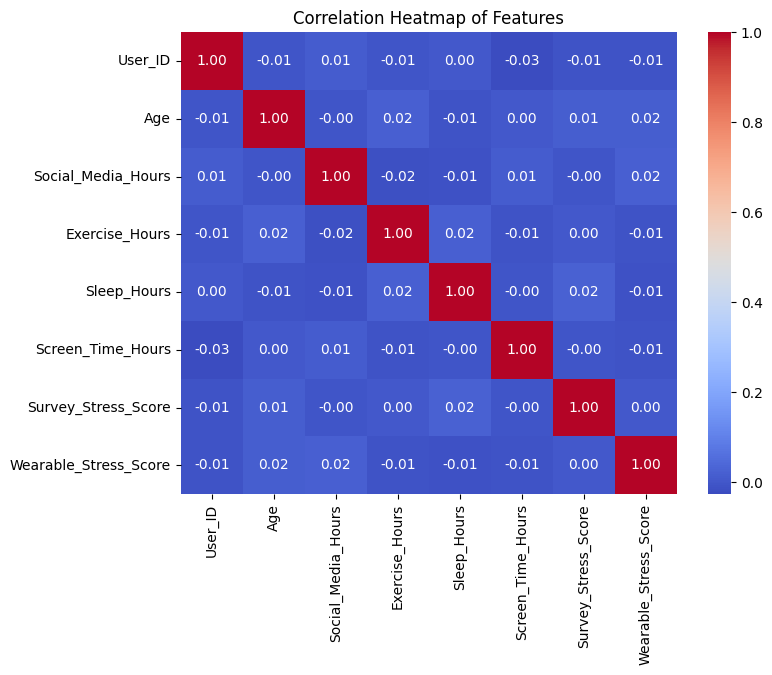

In [37]:
# Plot correlation heatmap
plt.figure(figsize=(8, 6))
# Select only numeric columns for correlation calculation
numeric_df = data.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()

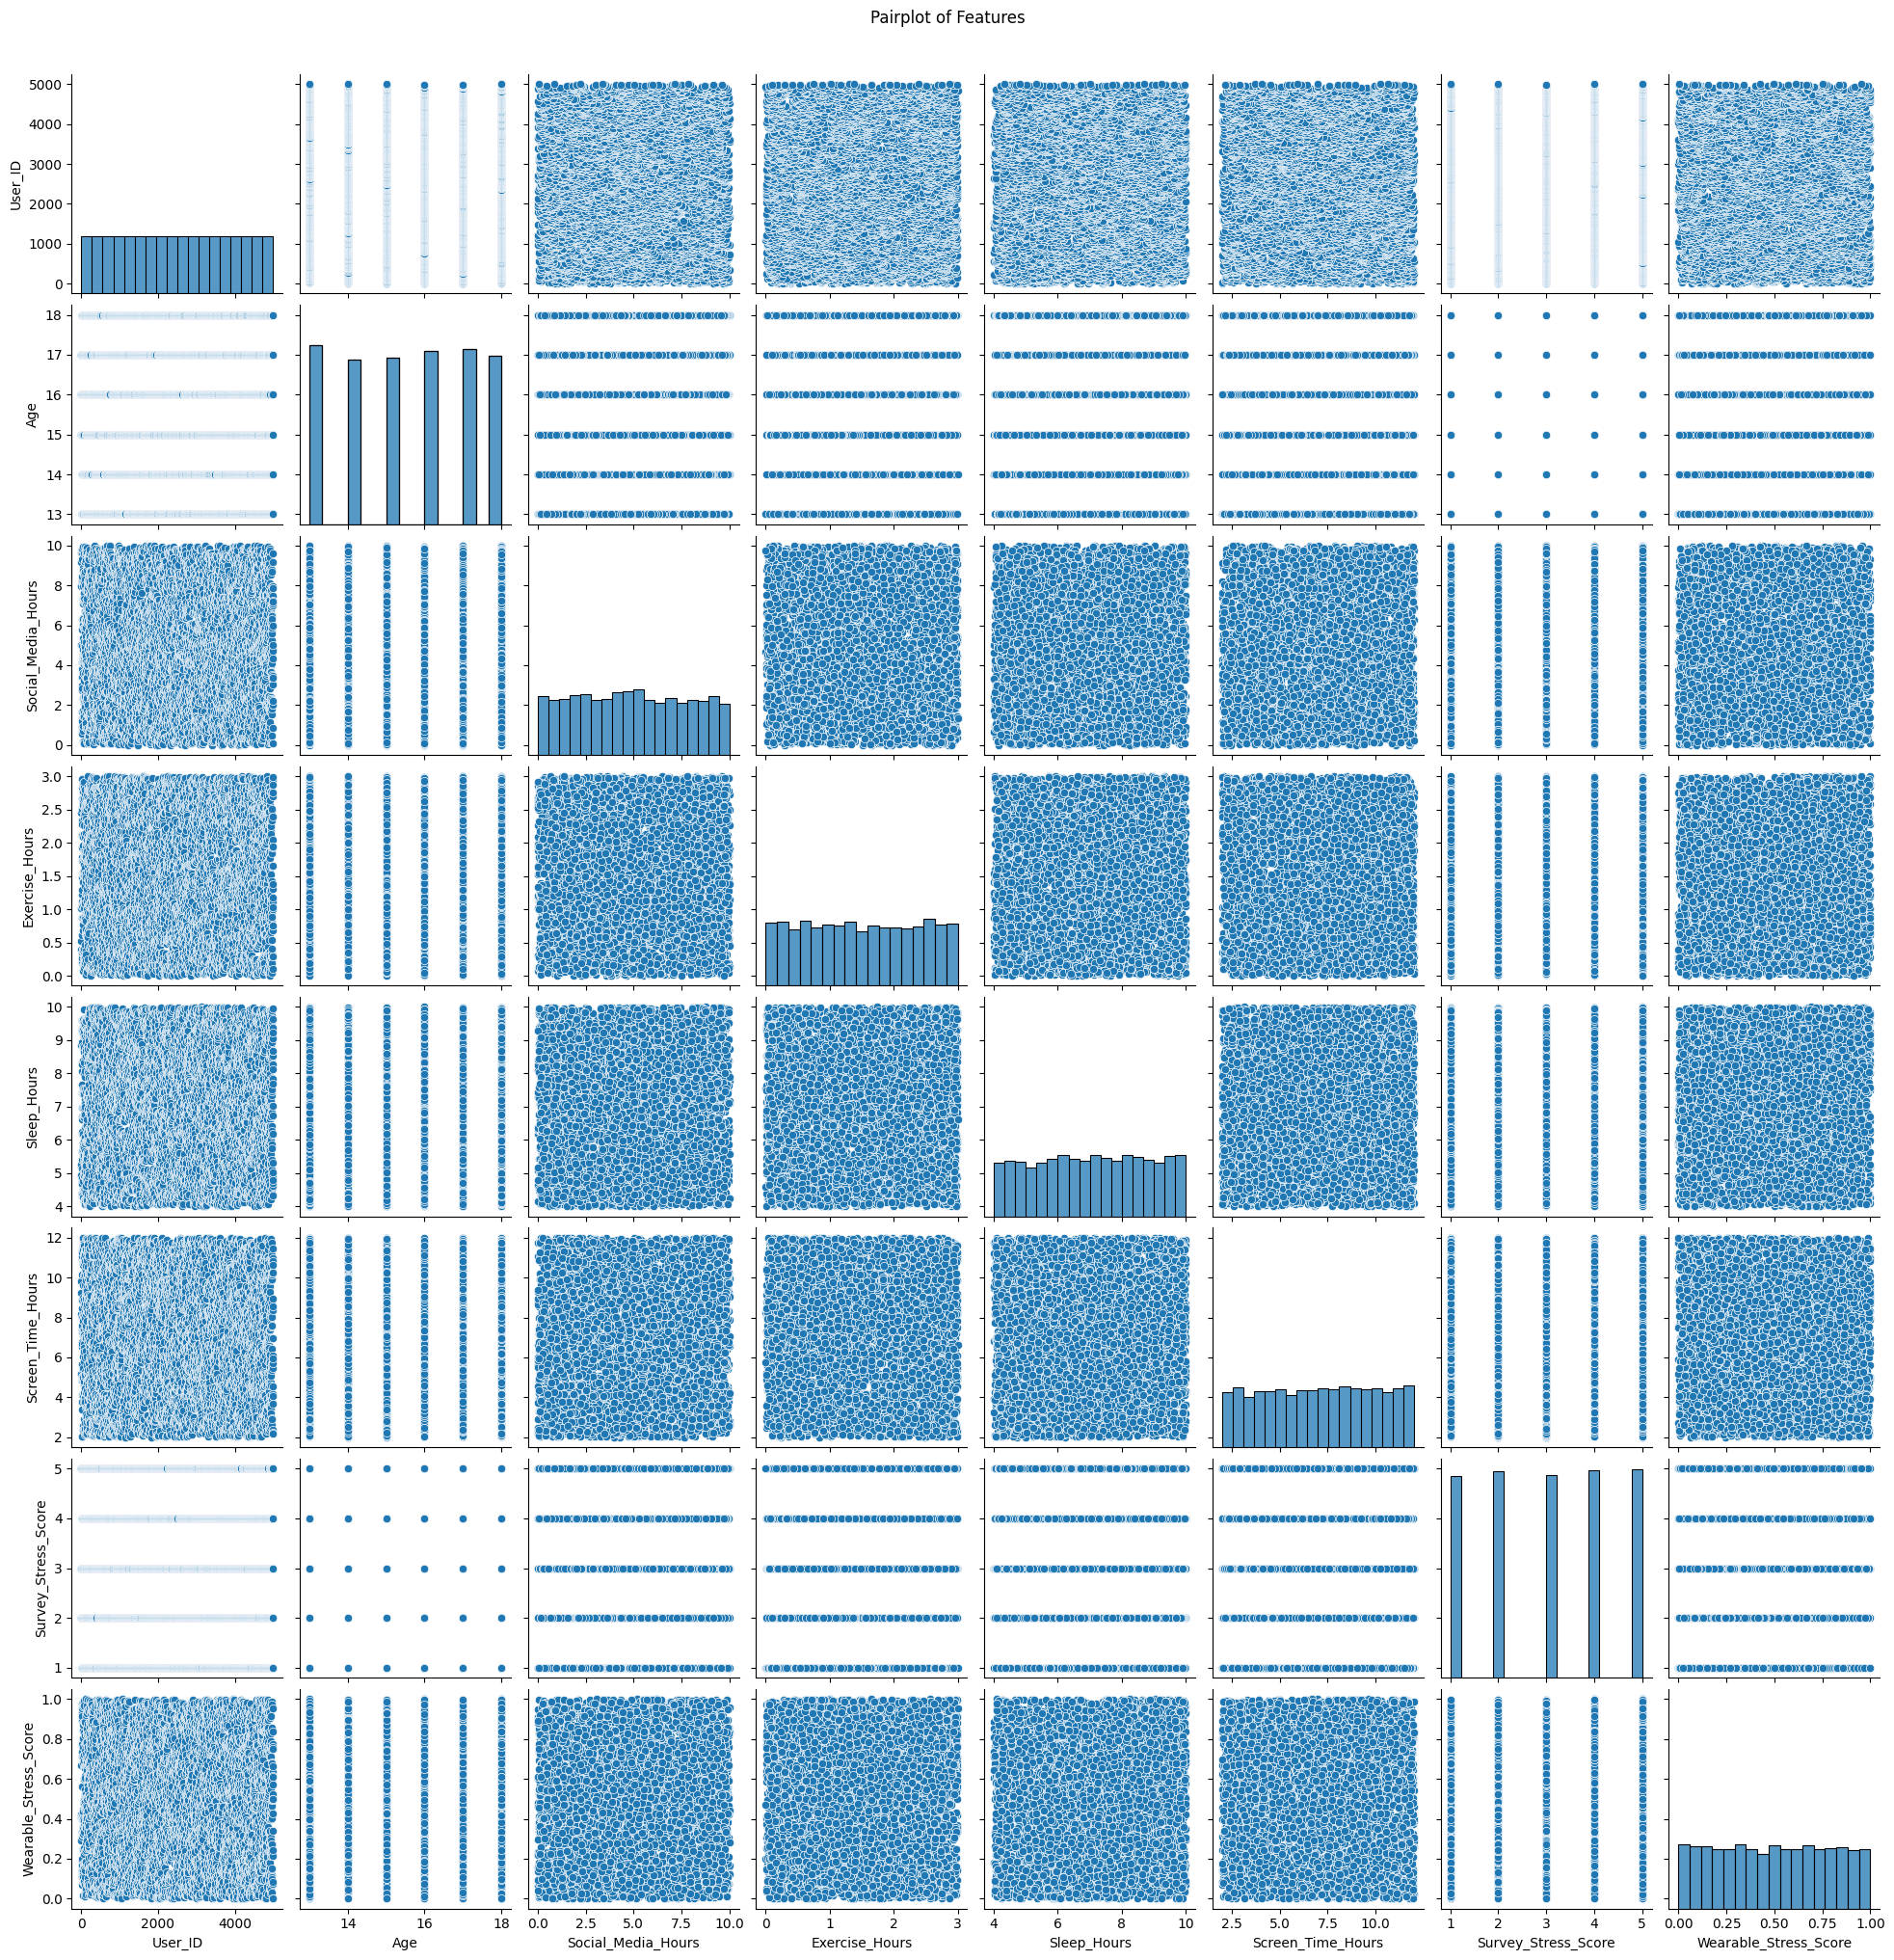

In [38]:

# 2. Pairplot (Scatterplot matrix)
sns.pairplot(numeric_df, diag_kind='hist', height=2.5)
plt.suptitle("Pairplot of Features", y=1.02)
plt.show()


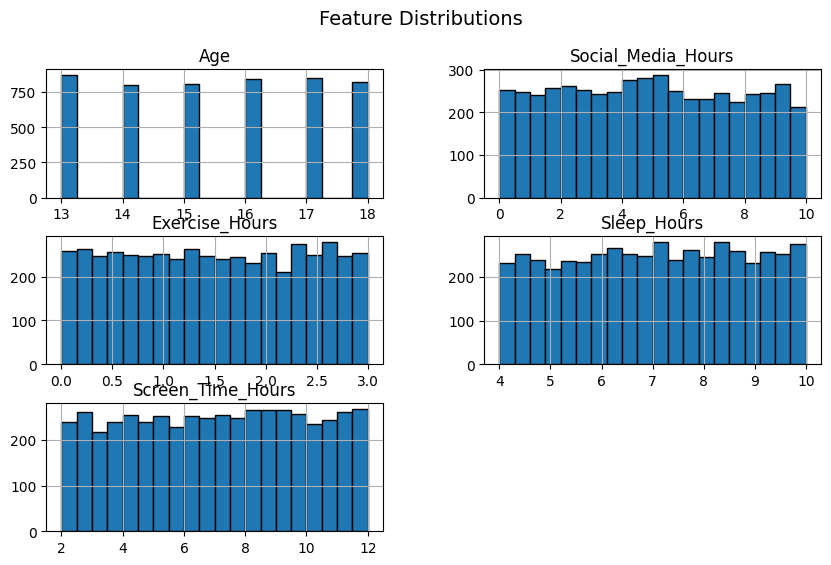

In [39]:
# Plot histograms for feature distributions
data[features].hist(figsize=(10, 6), bins=20, edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()


#🧮 Step 4: Implementing Linear Regression

Train a Linear Regression Model using scikit-learn



Linear Regression (Normal Equation) - Test MSE: 0.09, R²: -0.00


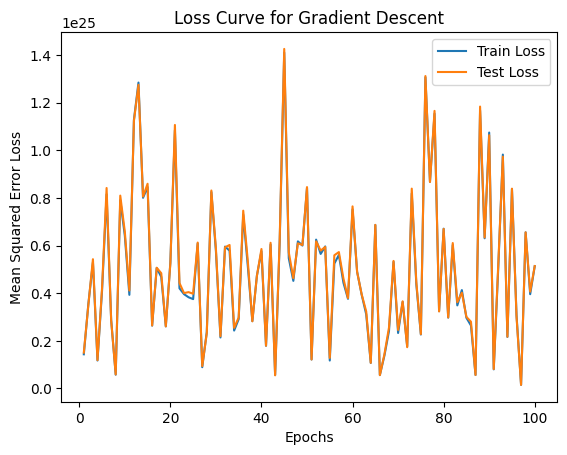

Linear Regression (Normal Equation) - MSE: 0.09, R²: -0.00
Linear Regression with Gradient Descent (SGDRegressor) - Final Train MSE: 5132519902933791948144640.00, Final Test MSE: 5137471564108783889154048.00
Decision Tree MSE: 0.17, R²: -1.00
Random Forest MSE: 0.09, R²: -0.04


In [57]:
# 1. Linear Regression using sklearn
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression (Normal Equation) - Test MSE: {mse_linear:.2f}, R²: {r2_linear:.2f}")

# 2. Linear Regression with Gradient Descent (SGDRegressor)
n_epochs = 100
gd_model = SGDRegressor(max_iter=1, tol=None, random_state=42, warm_start=True, learning_rate='constant', eta0=0.01)

train_losses = []
test_losses = []

for epoch in range(n_epochs):
    gd_model.fit(X_train, y_train)
    
    y_pred_gd_train = gd_model.predict(X_train)
    y_pred_gd_test = gd_model.predict(X_test)
    
    mse_gd_train = mean_squared_error(y_train, y_pred_gd_train)
    mse_gd_test = mean_squared_error(y_test, y_pred_gd_test)
    
    train_losses.append(mse_gd_train)
    test_losses.append(mse_gd_test)


# Plot Loss Curve
plt.plot(range(1, n_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, n_epochs+1), test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error Loss')
plt.legend()
plt.title('Loss Curve for Gradient Descent')
plt.show()



# 3. Decision Tree and Random Forest
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Model comparison
print(f'Linear Regression (Normal Equation) - MSE: {mse_linear:.2f}, R²: {r2_linear:.2f}')
print(f'Linear Regression with Gradient Descent (SGDRegressor) - Final Train MSE: {train_losses[-1]:.2f}, Final Test MSE: {test_losses[-1]:.2f}')
print(f'Decision Tree MSE: {mse_dt:.2f}, R²: {r2_dt:.2f}')
print(f'Random Forest MSE: {mse_rf:.2f}, R²: {r2_rf:.2f}')


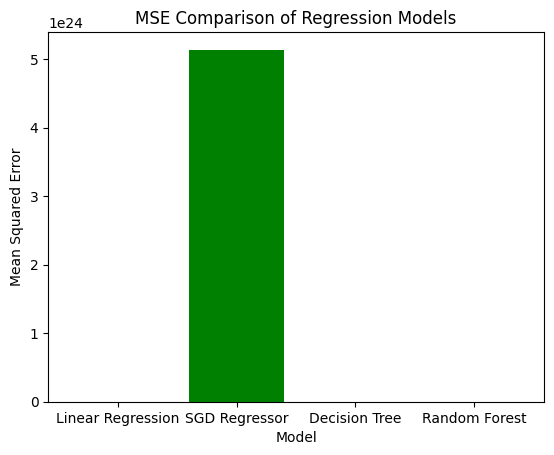

In [55]:
# Bar chart for model comparison based on MSE
models = ['Linear Regression', 'SGD Regressor', 'Decision Tree', 'Random Forest']
mse_values = [mse_linear, test_losses[-1], mse_dt, mse_rf]

plt.bar(models, mse_values, color=['blue', 'green', 'orange', 'red'])
plt.xlabel('Model')
plt.ylabel('Mean Squared Error')
plt.title('MSE Comparison of Regression Models')
plt.show()


#🏆 Step 7: Saving the Best Model

We'll save the model with the lowest loss.

In [52]:

# Save the best model based on the lowest MSE using joblib
best_model = min([(mse_linear, linear_model), (test_losses[-1], gd_model), (mse_dt, dt_model), (mse_rf, rf_model)], key=lambda x: x[0])[1]

# Print the selected model type
print(f"The best model based on MSE is: {best_model.__class__.__name__}")
      
joblib.dump(best_model, 'best_model.joblib')
print("Best model saved successfully!")


The best model based on MSE is: LinearRegression
Best model saved successfully!


#🎯 Step 8: Using the Best Model for Predictions
Now, let's load the best model and make a new prediction.

In [ ]:
# Predict on one sample from the test data (first row of X_test)
sample = X_test.iloc[0].values.reshape(1, -1)
prediction = best_model.predict(sample)
print(f"Prediction for sample input {sample.flatten()}: {prediction[0]:.2f}")


Prediction for sample input [[np.int64(14) 0 np.float64(4.927813459) np.float64(1.409406227)
  np.float64(9.299055824) np.float64(3.273760325) 0 1]]: 0.49
